<a href="https://colab.research.google.com/github/jajllc/FathersNotSpermDonors2/blob/main/MachineLearningBootcampCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project
## DevTown Machone Learning Bootcamp

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [5]:
df=pd.read_csv("customer_retail.csv")

In [6]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [7]:
df=df.dropna()

In [8]:
df=df[['Quantity', 'UnitPrice', 'Country']]

In [9]:
encoder=LabelEncoder()
df['Country_encoded']=encoder.fit_transform(df['Country'])

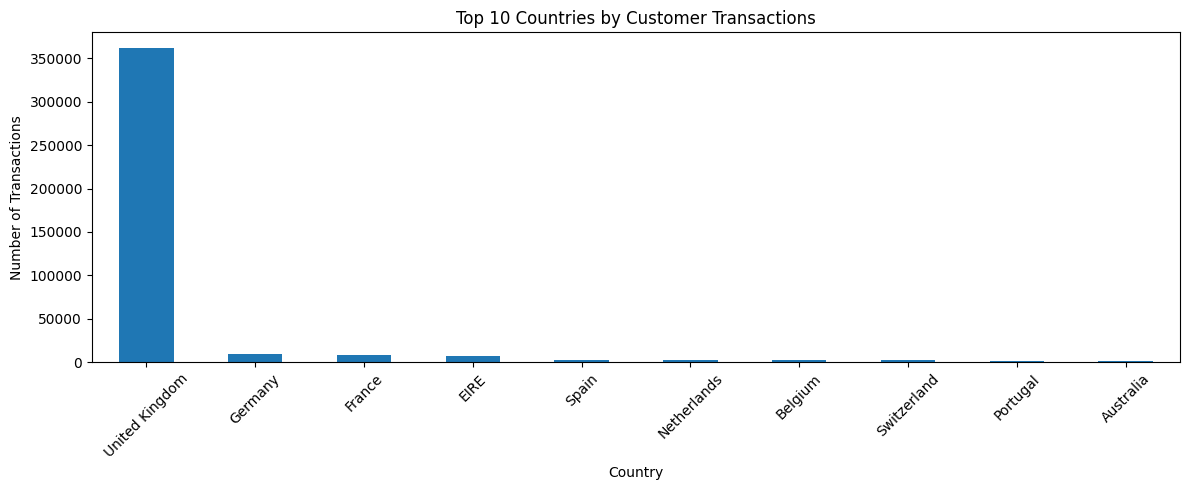

In [10]:
# Customer Distribution Graph
plt.figure(figsize=(12,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Customer Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

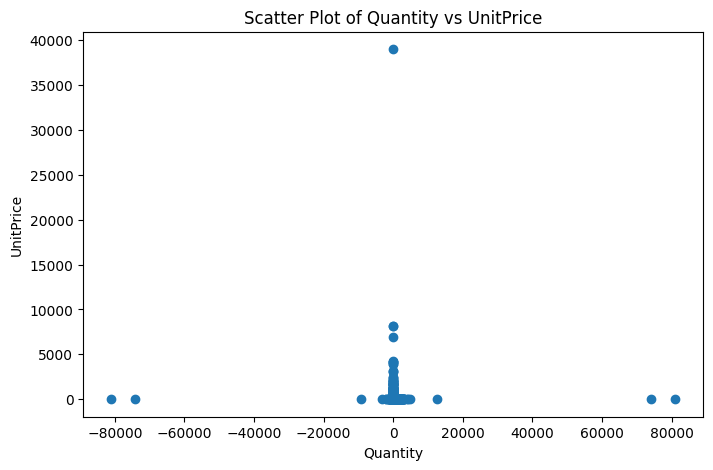

In [11]:
# Scatter Plot of Quantity vs UnitPrice
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

In [12]:
x=df[['Quantity', 'UnitPrice']]
y=df['Country_encoded']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)

from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Logistic Regression with more iterations and a stronger solver
print("Logistic Regression")
log_model = LogisticRegression(max_iter=5000, solver='saga')
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: ")
print(cm)

# Old code that caused iterations warning
# print("Logistic Regression")
# log_model=LogisticRegression()
# log_model.fit(x_train, y_train)
# y_pred=log_model.predict(x_test)
# accuracy=accuracy_score(y_test, y_pred)
# print("Accuracy: ", accuracy)
# cm=confusion_matrix(y_test, y_pred)
# print("Confusion Matrix: ")
# print(cm)

print("Decision Tree")
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred=dt_model.predict(x_test)

accuracy=accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(confusion_matrix(y_test, y_pred))

print("KNN")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train_scaled, y_train)
y_pred = knn_model.predict(x_test_scaled)

accuracy=accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(confusion_matrix(y_test, y_pred))

Logistic Regression
Accuracy:  0.88991716441757
Confusion Matrix: 
[[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0 72409     0]
 [    0     0     0 ...     0    43     0]]
Decision Tree
Accuracy:  0.8903350293734483
[[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   22     0     0 ...     1 72221     0]
 [    0     0     0 ...     0    43     0]]
KNN
Accuracy:  0.8849888159673573
[[   25     0     0 ...     0   181     0]
 [    0     1     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   34     0     0 ...     0 71742     0]
 [    0     0     0 ...     0    43     0]]


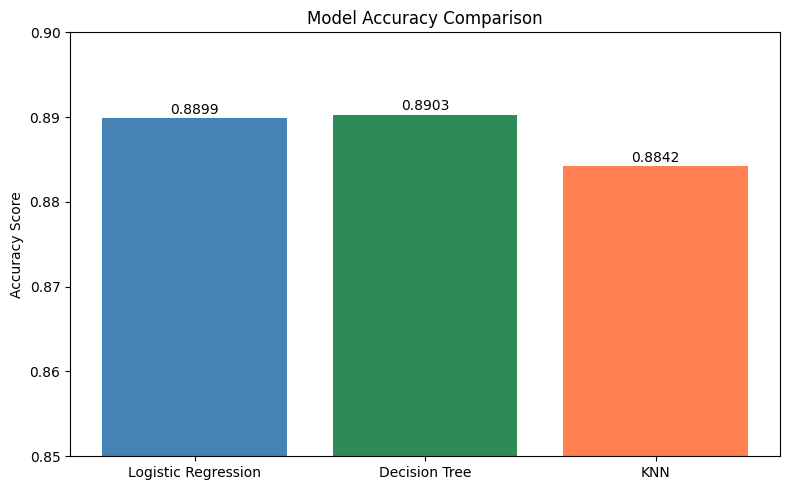

In [13]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [0.8899, 0.8903, 0.8842]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'coral'])
plt.ylim(0.85, 0.90)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Conclusion**

Three classification models were trained on the customer retail dataset to predict customer country based on Quantity and UnitPrice. Decision Tree achieved the highest accuracy at 89.03%, followed closely by Logistic Regression at 88.99% and KNN at 88.42%. The differences between models are small.

However, the high accuracy is misleading. The dataset is heavily imbalanced, with United Kingdom customers representing the majority of transactions. The confusion matrices show that all three models predict UK for nearly every input. A baseline model that always predicts UK would achieve similar accuracy without learning anything meaningful.

This project demonstrates an important lesson in machine learning: accuracy is not always a sufficient metric. For imbalanced datasets, additional metrics such as precision, recall, F1 score, or balanced accuracy provide a more honest picture of model performance. Feature selection also matters. Quantity and UnitPrice may not contain enough signal to reliably distinguish customer country, suggesting that additional features like product category, purchase time, or customer behavior patterns would improve the model.